Dataset Info:
Number of agents (m): 10
Number of jobs (n): 60
Total runs per approach: 20
Generations: 50
Population size: 30
PSO Parameters: W=0.7, C1=1.5, C2=1.5

RUNNING PENALTY METHOD
Run 1: Profit = 1437
Run 2: Profit = 1441
Run 3: Profit = 1436
Run 4: Profit = 1446
Run 5: Profit = 1431
Run 6: Profit = 1442
Run 7: Profit = 1438
Run 8: Profit = 1441
Run 9: Profit = 1441
Run 10: Profit = 1438
Run 11: Profit = 1432
Run 12: Profit = 1436
Run 13: Profit = 1442
Run 14: Profit = 1437
Run 15: Profit = 1438
Run 16: Profit = 1445
Run 17: Profit = 1437
Run 18: Profit = 1442
Run 19: Profit = 1435
Run 20: Profit = 1445

===== Penalty Method STATISTICS =====
Average Profit: 1439.00
Standard Deviation: 4.12
Best Profit: 1446
Worst Profit: 1431

----- Infeasible Solutions Statistics -----
Initial Infeasible Solutions (Gen 0): 0.0 out of 30
Final Infeasible Solutions (Gen 49): 0.0 out of 30
Average Infeasible Solutions across all generations: 0.0
Reduction in infeasible solutions: N/A (no initial 

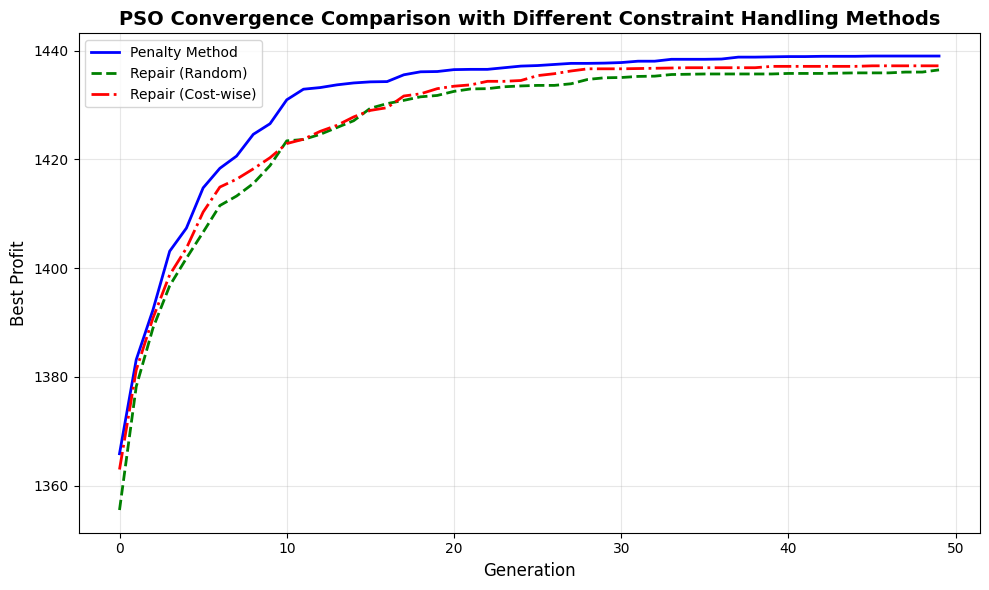


SUMMARY COMPARISON
Approach             Avg Profit      Std Dev    Best       Worst     
------------------------------------------------------------
Penalty Method       1439.00         4.12       1446       1431      
Repair (Random)      1436.45         8.03       1446       1409      
Repair (Cost-wise)   1437.20         6.09       1446       1422      

BEST APPROACH: Penalty Method
Average Profit: 1439.00
Best Profit Achieved: 1446

INFEASIBLE SOLUTIONS REDUCTION COMPARISON
Penalty Method      : Initial=0.0, Final=0.0, Reduction=N/A (no initial infeasible solutions)
Repair (Random)     : Initial=0.0, Final=0.0, Reduction=N/A (no initial infeasible solutions)
Repair (Cost-wise)  : Initial=0.0, Final=0.0, Reduction=N/A (no initial infeasible solutions)


In [2]:
import random
import statistics
import matplotlib.pyplot as plt
import math

# ==================================================
# PARAMETERS
POP_SIZE = 30
GENERATIONS = 50
RUNS = 20

W = 0.7
C1 = 1.5
C2 = 1.5

# ==================================================
# READ GAP FILE
def read_gap_instances(filename):
    with open(filename, 'r') as f:
        data = list(map(int, f.read().split()))

    idx = 0
    num_instances = data[idx]
    idx += 1

    instances = []

    for _ in range(num_instances):
        m = data[idx]
        n = data[idx + 1]
        idx += 2

        c = []
        for _ in range(m):
            c.append(data[idx:idx + n])
            idx += n

        a = []
        for _ in range(m):
            a.append(data[idx:idx + n])
            idx += n

        b = data[idx:idx + m]
        idx += m

        instances.append((c, a, b))

    return instances

# ==================================================
# DECODER WITH ASSIGNMENT INFO (using keys/priorities)
def decode_with_assignment(keys, c, a, b):
    m, n = len(b), len(keys)

    order = sorted(range(n), key=lambda j: keys[j], reverse=True)

    remaining = b.copy()
    profit = 0
    assignment = [-1] * n

    for j in order:
        best_agent = None
        best_profit = -1

        for i in range(m):
            if remaining[i] >= a[i][j] and c[i][j] > best_profit:
                best_agent = i
                best_profit = c[i][j]

        if best_agent is not None:
            assignment[j] = best_agent
            remaining[best_agent] -= a[best_agent][j]
            profit += c[best_agent][j]

    return assignment, profit, remaining

def decode(keys, c, a, b):
    _, profit, _ = decode_with_assignment(keys, c, a, b)
    return profit

# ==================================================
# CHECK FEASIBILITY
def is_feasible(remaining, b):
    """Check if all resource constraints are satisfied"""
    return all(remaining[i] >= 0 for i in range(len(b)))

def is_feasible_by_assignment(assignment, a, b):
    m = len(b)
    used = [0] * m
    
    for j, i in enumerate(assignment):
        if i != -1:
            used[i] += a[i][j]
    
    return all(used[i] <= b[i] for i in range(m))

# ==================================================
# APPROACH 1: PENALTY METHOD
def decode_penalty(keys, c, a, b, penalty_factor=1000):
    assignment, profit, remaining = decode_with_assignment(keys, c, a, b)
    
    # Calculate total resource violation
    violation = 0
    for i in range(len(b)):
        if remaining[i] < 0:
            violation += abs(remaining[i])
    
    # Apply penalty
    penalized_profit = profit - penalty_factor * violation
    return penalized_profit, violation, remaining

def run_pso_penalty(c, a, b):
    n = len(c[0])

    particles = [[random.random() for _ in range(n)] for _ in range(POP_SIZE)]
    velocities = [[random.uniform(-0.1, 0.1) for _ in range(n)] for _ in range(POP_SIZE)]

    pbest = [p[:] for p in particles]
    pbest_fit = []
    infeasible_count_per_gen = []

    # Initial evaluation
    infeasible_gen = 0
    for p in particles:
        fit, viol, _ = decode_penalty(p, c, a, b)
        pbest_fit.append(fit)
        if viol > 0:
            infeasible_gen += 1
    
    infeasible_count_per_gen.append(infeasible_gen)

    gbest_idx = pbest_fit.index(max(pbest_fit))
    gbest = pbest[gbest_idx][:]
    gbest_fit = max(pbest_fit)

    convergence = [gbest_fit]

    # PSO iterations
    for gen in range(1, GENERATIONS):
        infeasible_gen = 0
        
        for i in range(POP_SIZE):
            for j in range(n):
                r1, r2 = random.random(), random.random()
                
                velocities[i][j] = (W * velocities[i][j] + 
                                   C1 * r1 * (pbest[i][j] - particles[i][j]) + 
                                   C2 * r2 * (gbest[j] - particles[i][j]))
                
                particles[i][j] += velocities[i][j]
                particles[i][j] = max(0, min(1, particles[i][j]))
            
            fit, viol, _ = decode_penalty(particles[i], c, a, b)
            
            if viol > 0:
                infeasible_gen += 1
            
            if fit > pbest_fit[i]:
                pbest[i] = particles[i][:]
                pbest_fit[i] = fit
        
        # Update global best
        current_best_idx = pbest_fit.index(max(pbest_fit))
        if pbest_fit[current_best_idx] > gbest_fit:
            gbest = pbest[current_best_idx][:]
            gbest_fit = pbest_fit[current_best_idx]
        
        convergence.append(gbest_fit)
        infeasible_count_per_gen.append(infeasible_gen)

    return gbest_fit, convergence, infeasible_count_per_gen

# ==================================================
# APPROACH 2: REPAIR WITH RANDOM SOLUTION
def repair_random(assignment, remaining, a, b, c):
    """Repair infeasible solution by randomly reassigning problematic jobs"""
    m, n = len(b), len(assignment)
    
    # Find overloaded agents
    overloaded = [i for i in range(m) if remaining[i] < 0]
    
    if not overloaded:
        return assignment, remaining
    
    # List jobs to reassign (jobs assigned to overloaded agents)
    jobs_to_reassign = []
    for j in range(n):
        if assignment[j] in overloaded:
            jobs_to_reassign.append(j)
    
    # Randomly reassign jobs
    remaining_copy = remaining.copy()
    new_assignment = assignment.copy()
    
    # Remove problematic assignments first
    for j in jobs_to_reassign:
        if new_assignment[j] != -1:
            remaining_copy[new_assignment[j]] += a[new_assignment[j]][j]
            new_assignment[j] = -1
    
    # Try to reassign in random order
    random.shuffle(jobs_to_reassign)
    
    for j in jobs_to_reassign:
        possible_agents = [i for i in range(m) if remaining_copy[i] >= a[i][j]]
        
        if possible_agents:
            agent = random.choice(possible_agents)
            new_assignment[j] = agent
            remaining_copy[agent] -= a[agent][j]
    
    # Calculate new profit
    profit = 0
    for j in range(n):
        if new_assignment[j] != -1:
            profit += c[new_assignment[j]][j]
    
    return new_assignment, remaining_copy

def decode_repair_random(keys, c, a, b):
    assignment, profit, remaining = decode_with_assignment(keys, c, a, b)
    
    if not is_feasible(remaining, b):
        assignment, remaining = repair_random(assignment, remaining, a, b, c)
        # Recalculate profit
        profit = 0
        for j in range(len(assignment)):
            if assignment[j] != -1:
                profit += c[assignment[j]][j]
    
    return profit, assignment, remaining

def run_pso_repair_random(c, a, b):
    n = len(c[0])

    particles = [[random.random() for _ in range(n)] for _ in range(POP_SIZE)]
    velocities = [[random.uniform(-0.1, 0.1) for _ in range(n)] for _ in range(POP_SIZE)]

    pbest = [p[:] for p in particles]
    pbest_fit = []
    infeasible_count_per_gen = []

    # Initial evaluation
    infeasible_gen = 0
    for p in particles:
        fit, assignment, remaining = decode_repair_random(p, c, a, b)
        pbest_fit.append(fit)
        # Check if original solution was infeasible
        _, _, original_remaining = decode_with_assignment(p, c, a, b)
        if not is_feasible(original_remaining, b):
            infeasible_gen += 1
    
    infeasible_count_per_gen.append(infeasible_gen)

    gbest_idx = pbest_fit.index(max(pbest_fit))
    gbest = pbest[gbest_idx][:]
    gbest_fit = max(pbest_fit)

    convergence = [gbest_fit]

    # PSO iterations
    for gen in range(1, GENERATIONS):
        infeasible_gen = 0
        
        for i in range(POP_SIZE):
            for j in range(n):
                r1, r2 = random.random(), random.random()
                
                velocities[i][j] = (W * velocities[i][j] + 
                                   C1 * r1 * (pbest[i][j] - particles[i][j]) + 
                                   C2 * r2 * (gbest[j] - particles[i][j]))
                
                particles[i][j] += velocities[i][j]
                particles[i][j] = max(0, min(1, particles[i][j]))
            
            fit, assignment, remaining = decode_repair_random(particles[i], c, a, b)
            
            # Check if original solution was infeasible
            _, _, original_remaining = decode_with_assignment(particles[i], c, a, b)
            if not is_feasible(original_remaining, b):
                infeasible_gen += 1
            
            if fit > pbest_fit[i]:
                pbest[i] = particles[i][:]
                pbest_fit[i] = fit
        
        # Update global best
        current_best_idx = pbest_fit.index(max(pbest_fit))
        if pbest_fit[current_best_idx] > gbest_fit:
            gbest = pbest[current_best_idx][:]
            gbest_fit = pbest_fit[current_best_idx]
        
        convergence.append(gbest_fit)
        infeasible_count_per_gen.append(infeasible_gen)

    return gbest_fit, convergence, infeasible_count_per_gen

# ==================================================
# APPROACH 3: REPAIR WITH COST-WISE (MINIMUM COST LOSS)
def repair_cost_wise(assignment, remaining, a, b, c):
    """Repair infeasible solution by reassigning jobs to minimize cost loss"""
    m, n = len(b), len(assignment)
    
    # Find overloaded agents
    overloaded = [i for i in range(m) if remaining[i] < 0]
    
    if not overloaded:
        return assignment, remaining
    
    # List jobs to reassign with their current profit
    jobs_info = []
    for j in range(n):
        if assignment[j] in overloaded:
            jobs_info.append((j, assignment[j], c[assignment[j]][j]))
    
    # Sort jobs by profit (lowest profit first - cheaper to reassign)
    jobs_info.sort(key=lambda x: x[2])
    
    remaining_copy = remaining.copy()
    new_assignment = assignment.copy()
    
    # Remove problematic assignments
    for j, old_agent, _ in jobs_info:
        if new_assignment[j] != -1:
            remaining_copy[old_agent] += a[old_agent][j]
            new_assignment[j] = -1
    
    # Try to reassign starting from lowest profit jobs
    for j, _, _ in jobs_info:
        # Find feasible agents sorted by cost (minimum cost loss)
        feasible_agents = []
        for i in range(m):
            if remaining_copy[i] >= a[i][j]:
                feasible_agents.append((i, c[i][j]))
        
        if feasible_agents:
            # Choose agent with maximum profit (minimum loss)
            best_agent = max(feasible_agents, key=lambda x: x[1])[0]
            new_assignment[j] = best_agent
            remaining_copy[best_agent] -= a[best_agent][j]
    
    # Calculate new profit
    profit = 0
    for j in range(n):
        if new_assignment[j] != -1:
            profit += c[new_assignment[j]][j]
    
    return new_assignment, remaining_copy

def decode_repair_costwise(keys, c, a, b):
    assignment, profit, remaining = decode_with_assignment(keys, c, a, b)
    
    if not is_feasible(remaining, b):
        assignment, remaining = repair_cost_wise(assignment, remaining, a, b, c)
        # Recalculate profit
        profit = 0
        for j in range(len(assignment)):
            if assignment[j] != -1:
                profit += c[assignment[j]][j]
    
    return profit, assignment, remaining

def run_pso_repair_costwise(c, a, b):
    n = len(c[0])

    particles = [[random.random() for _ in range(n)] for _ in range(POP_SIZE)]
    velocities = [[random.uniform(-0.1, 0.1) for _ in range(n)] for _ in range(POP_SIZE)]

    pbest = [p[:] for p in particles]
    pbest_fit = []
    infeasible_count_per_gen = []

    # Initial evaluation
    infeasible_gen = 0
    for p in particles:
        fit, assignment, remaining = decode_repair_costwise(p, c, a, b)
        pbest_fit.append(fit)
        # Check if original solution was infeasible
        _, _, original_remaining = decode_with_assignment(p, c, a, b)
        if not is_feasible(original_remaining, b):
            infeasible_gen += 1
    
    infeasible_count_per_gen.append(infeasible_gen)

    gbest_idx = pbest_fit.index(max(pbest_fit))
    gbest = pbest[gbest_idx][:]
    gbest_fit = max(pbest_fit)

    convergence = [gbest_fit]

    # PSO iterations
    for gen in range(1, GENERATIONS):
        infeasible_gen = 0
        
        for i in range(POP_SIZE):
            for j in range(n):
                r1, r2 = random.random(), random.random()
                
                velocities[i][j] = (W * velocities[i][j] + 
                                   C1 * r1 * (pbest[i][j] - particles[i][j]) + 
                                   C2 * r2 * (gbest[j] - particles[i][j]))
                
                particles[i][j] += velocities[i][j]
                particles[i][j] = max(0, min(1, particles[i][j]))
            
            fit, assignment, remaining = decode_repair_costwise(particles[i], c, a, b)
            
            # Check if original solution was infeasible
            _, _, original_remaining = decode_with_assignment(particles[i], c, a, b)
            if not is_feasible(original_remaining, b):
                infeasible_gen += 1
            
            if fit > pbest_fit[i]:
                pbest[i] = particles[i][:]
                pbest_fit[i] = fit
        
        # Update global best
        current_best_idx = pbest_fit.index(max(pbest_fit))
        if pbest_fit[current_best_idx] > gbest_fit:
            gbest = pbest[current_best_idx][:]
            gbest_fit = pbest_fit[current_best_idx]
        
        convergence.append(gbest_fit)
        infeasible_count_per_gen.append(infeasible_gen)

    return gbest_fit, convergence, infeasible_count_per_gen

# ==================================================
# RUN EXPERIMENTS FOR ALL APPROACHES
def run_experiment_comparison(c, a, b):
    approaches = {
        'Penalty Method': run_pso_penalty,
        'Repair (Random)': run_pso_repair_random,
        'Repair (Cost-wise)': run_pso_repair_costwise
    }
    
    results = {}
    
    for approach_name, run_func in approaches.items():
        print(f"\n{'='*60}")
        print(f"RUNNING {approach_name.upper()}")
        print(f"{'='*60}")
        
        profits = []
        all_convergence = []
        all_infeasible = []
        
        for r in range(RUNS):
            best, conv, infeas = run_func(c, a, b)
            print(f"Run {r+1}: Profit = {best}")
            
            profits.append(best)
            all_convergence.append(conv)
            all_infeasible.append(infeas)
        
        # Statistics
        avg = sum(profits) / RUNS
        std = statistics.stdev(profits) if len(profits) > 1 else 0
        
        print(f"\n===== {approach_name} STATISTICS =====")
        print(f"Average Profit: {avg:.2f}")
        print(f"Standard Deviation: {std:.2f}")
        print(f"Best Profit: {max(profits)}")
        print(f"Worst Profit: {min(profits)}")
        
        # Infeasible solutions statistics
        if all_infeasible and all_infeasible[0]:
            # Calculate average infeasible solutions per generation
            min_len = min(len(inf) for inf in all_infeasible)
            trimmed_infeasible = [inf[:min_len] for inf in all_infeasible]
            avg_infeasible_per_gen = [sum(x)/RUNS for x in zip(*trimmed_infeasible)]
            
            print(f"\n----- Infeasible Solutions Statistics -----")
            print(f"Initial Infeasible Solutions (Gen 0): {avg_infeasible_per_gen[0]:.1f} out of {POP_SIZE}")
            print(f"Final Infeasible Solutions (Gen {GENERATIONS-1}): {avg_infeasible_per_gen[-1]:.1f} out of {POP_SIZE}")
            print(f"Average Infeasible Solutions across all generations: {sum(avg_infeasible_per_gen)/len(avg_infeasible_per_gen):.1f}")
            
            # Handle division by zero for reduction calculation
            if avg_infeasible_per_gen[0] > 0:
                reduction = ((avg_infeasible_per_gen[0] - avg_infeasible_per_gen[-1]) / avg_infeasible_per_gen[0] * 100)
                print(f"Reduction in infeasible solutions: {reduction:.1f}%")
            else:
                print(f"Reduction in infeasible solutions: N/A (no initial infeasible solutions)")
        else:
            print(f"\n----- Infeasible Solutions Statistics -----")
            print("No infeasible tracking data available for this approach")
            avg_infeasible_per_gen = []
        
        # Average convergence
        min_len = min(len(conv) for conv in all_convergence)
        trimmed_convergence = [conv[:min_len] for conv in all_convergence]
        avg_conv = [sum(x)/RUNS for x in zip(*trimmed_convergence)]
        
        results[approach_name] = {
            'profits': profits,
            'avg_conv': avg_conv,
            'avg_infeasible': avg_infeasible_per_gen if all_infeasible and all_infeasible[0] else [],
            'avg_profit': avg,
            'std': std,
            'best': max(profits),
            'worst': min(profits)
        }
    
    # Create convergence plot
    plt.figure(figsize=(10, 6))
    
    colors = ['blue', 'green', 'red']
    line_styles = ['-', '--', '-.']
    
    for idx, (name, data) in enumerate(results.items()):
        plt.plot(data['avg_conv'], linewidth=2, color=colors[idx], 
                linestyle=line_styles[idx], label=name)
    
    plt.xlabel("Generation", fontsize=12)
    plt.ylabel("Best Profit", fontsize=12)
    plt.title("PSO Convergence Comparison with Different Constraint Handling Methods", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary comparison
    print(f"\n{'='*60}")
    print("SUMMARY COMPARISON")
    print(f"{'='*60}")
    print(f"{'Approach':<20} {'Avg Profit':<15} {'Std Dev':<10} {'Best':<10} {'Worst':<10}")
    print(f"{'-'*60}")
    for name, data in results.items():
        print(f"{name:<20} {data['avg_profit']:<15.2f} {data['std']:<10.2f} {data['best']:<10} {data['worst']:<10}")
    
    # Determine best approach
    best_approach = max(results.items(), key=lambda x: x[1]['avg_profit'])
    print(f"\n{'='*60}")
    print(f"BEST APPROACH: {best_approach[0]}")
    print(f"Average Profit: {best_approach[1]['avg_profit']:.2f}")
    print(f"Best Profit Achieved: {best_approach[1]['best']}")
    
    # Compare infeasible solution reduction
    print(f"\n{'='*60}")
    print("INFEASIBLE SOLUTIONS REDUCTION COMPARISON")
    print(f"{'='*60}")
    for name, data in results.items():
        if data['avg_infeasible']:
            if data['avg_infeasible'][0] > 0:
                reduction = ((data['avg_infeasible'][0] - data['avg_infeasible'][-1]) / data['avg_infeasible'][0] * 100)
                print(f"{name:<20}: Initial={data['avg_infeasible'][0]:.1f}, Final={data['avg_infeasible'][-1]:.1f}, Reduction={reduction:.1f}%")
            else:
                print(f"{name:<20}: Initial={data['avg_infeasible'][0]:.1f}, Final={data['avg_infeasible'][-1]:.1f}, Reduction=N/A (no initial infeasible solutions)")
        else:
            print(f"{name:<20}: No infeasible data available")
    
    print(f"{'='*60}")

# ==================================================
# MAIN
file_path = r"gap12.txt"

instances = read_gap_instances(file_path)

# Use first instance
c, a, b = instances[0]

print("Dataset Info:")
print(f"Number of agents (m): {len(b)}")
print(f"Number of jobs (n): {len(c[0])}")
print(f"Total runs per approach: {RUNS}")
print(f"Generations: {GENERATIONS}")
print(f"Population size: {POP_SIZE}")
print(f"PSO Parameters: W={W}, C1={C1}, C2={C2}")

# Run comparison of all three approaches
run_experiment_comparison(c, a, b)